# 02 · Tool Use — give the agent access to external tools

> **TL;DR.** Bind one or more *tools* (Python functions exposed to the LLM via a JSON schema) to the model. The LLM decides when to call a tool, reads the tool's result, and either calls another tool or produces a final answer. The simplest "agentic" pattern that goes beyond a single forward pass.
>
> **Reach for it when** the answer requires information the model can't have memorized: live data (weather, stock prices, news), private data (your company's docs), or deterministic computation (math, code execution).
> **Avoid when** the answer is in the model's training data and structured output would do — calling a tool you don't need adds latency and one more failure point.

| Property | Value |
|---|---|
| Origin | OpenAI function-calling API, June 2023 — conceptual ancestor: Toolformer (Schick et al., 2023) |
| Reasoning type | Reactive (no explicit *thought* step — see ReAct, notebook 03, for that) |
| External tools needed? | **Yes** (web search by default) |
| Memory across episodes? | No |
| Provider requirement | Must support **tool calling** (Nebius, OpenAI, Anthropic, Groq, Together, Fireworks, Mistral, Google, recent Ollama) |
| Typical tool calls | 1–4 per task |

This notebook keeps the original scenario (research assistant doing live web queries) but rebuilds the implementation on top of the library's `ToolUse` class.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([user task]) --> AG[Agent<br/><sub>LLM bound with tools</sub>]
    AG --> Q{tool_calls<br/>present?}
    Q -->|yes| T[ToolNode<br/><sub>executes the called tools</sub>]
    T --> AG
    Q -->|no| F([final answer])

    style AG fill:#e3f2fd,stroke:#1976d2
    style T fill:#fff3e0,stroke:#f57c00
```

The graph has only two nodes: an **Agent** (the LLM with `bind_tools(...)`) and a **ToolNode** (LangGraph's prebuilt that calls the requested tools in parallel). `tools_condition` — also a LangGraph prebuilt — inspects the latest message and routes to `tools` if there are pending tool calls, else to `END`.

## 3 · Theory

### 3.1 · The shift from "completion" to "tool-augmented agent"

Before tool-calling (mid-2023), the LLM produced a single chunk of text in response to a prompt. Anything that required *up-to-date facts*, *private data*, or *arithmetic the model can't do reliably* had to be handled with awkward workarounds — ReAct-style prompting, plugins, or downstream scaffolding that parsed natural-language pseudo-commands out of the output.

OpenAI's function-calling API changed the game by training models to emit a **structured `tool_calls` field** rather than embedding tool invocations in free text. Now the LLM produces:

```json
{
  "tool_calls": [
    {"name": "web_search", "args": {"query": "LangGraph release date"}}
  ]
}
```

— which downstream code can execute deterministically. After execution, the tool's result is appended to the conversation as a `ToolMessage`, the LLM is invoked again, and it sees both the original request and the tool output before deciding what to do next.

### 3.2 · The minimal control loop

```python
while True:
    response = llm_with_tools.invoke(messages)
    messages.append(response)
    if not response.tool_calls:
        return response.content       # final answer
    for tc in response.tool_calls:
        result = run_tool(tc.name, tc.args)
        messages.append(ToolMessage(content=result, tool_call_id=tc.id))
```

LangGraph's `StateGraph + ToolNode + tools_condition` is exactly this loop, expressed as a graph so it's stoppable, observable in LangSmith, and replaceable with a more elaborate routing strategy when you grow into ReAct (notebook 03), Planning (notebook 04), or PEV (notebook 06).

### 3.3 · Where Tool Use sits in the taxonomy

| Pattern | Loop body | Thought step? | Plan ahead? | Use this when... |
|---|---|---|---|---|
| **Tool Use** *(this notebook)* | act → observe | no | no | a single query benefits from one or two external calls |
| ReAct (nb 03) | think → act → observe | **yes** | no | multi-step reasoning needs intermediate thoughts to stay coherent |
| Planning (nb 04) | plan once → execute step-by-step | no | **yes** | the task naturally decomposes into a fixed sequence |
| PEV (nb 06) | plan → exec → verify → maybe replan | no | yes + verification | actions can fail and you need automatic recovery |
| Agentic RAG (nb 23) | decide-to-retrieve → retrieve → answer | yes | no | the agent owns *when* to retrieve, not just *what* |

Tool Use is the "single forward step" version of ReAct. If you find yourself wanting the agent to write a *because-of-this* sentence between tool calls, you've grown into ReAct.

### 3.4 · The three failure modes you'll see in § 9

1. **Over-search** — the agent keeps calling the search tool even after it has enough information. Fix: a system prompt that explicitly tells it to stop after 2–3 calls (we use this).
2. **Result drift** — the agent searches, gets a relevant result, then *answers from parametric knowledge anyway*, ignoring the result. We'll see this live in the captured run.
3. **Bad query selection** — the agent issues queries that are too vague to be useful ("information about X" instead of "X release date 2024"). Tool Use has no built-in fix; ReAct's *thought* step is the standard upgrade.


## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import ToolUse
from agentic_architectures.ui import print_md, print_header, print_step

traced = enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")
print_md(f"LangSmith tracing: {'enabled' if traced else 'disabled (no LANGSMITH_API_KEY)'}")
print_md(f"Tavily key set: **{settings.tavily_api_key is not None}**")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

LangSmith tracing: enabled

Tavily key set: True

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/tool_use.py`](../src/agentic_architectures/architectures/tool_use.py).

The class is short — most of the heavy lifting is done by LangGraph prebuilts (`ToolNode`, `tools_condition`) and the library's `web_search_tool` wrapper around `langchain_tavily.TavilySearch` (which replaces the deprecated `TavilySearchResults` from the original repo).

Key design choices:

1. **`provider_supports_tools()` check at construction time.** Fails fast with a helpful error if you try Tool Use on a provider that doesn't support tool-calling (e.g., `huggingface`).
2. **Default system prompt** caps over-search ("after at most 2–3 searches, STOP and answer"). The original `bind_tools(...)` call alone produces 6+ searches per question for chatty models like Llama 3.3 — see § 9.
3. **Single `_agent` node** that prepends the system message on first turn only. `add_messages` reducer takes care of the rest.
4. **`recursion_limit = 4 × max_rounds + 4`** — LangGraph counts edge traversals, so we budget generously.

In [2]:
import inspect, ast
from agentic_architectures.architectures import tool_use as tu_mod

src = inspect.getsource(tu_mod.ToolUse)
tree = ast.parse(src)
for node in ast.walk(tree):
    if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
        args = ', '.join(a.arg for a in node.args.args if a.arg != 'self')
        print(f"def {node.name}({args}):")
print()
print('Default system prompt:')
print(tu_mod.ToolUse.DEFAULT_SYSTEM_PROMPT)

def __init__(tools, max_rounds, system_prompt):
def _agent(state):
def build():
def run(task):

Default system prompt:
You are a research assistant with access to web search.

Rules:
1. Use the search tool only when you need facts you don't already know.
2. After at most 2-3 searches, STOP searching and answer using what you found.
3. Cite your sources with URLs in the final answer.
4. If a search returns enough information, do NOT search again - answer the user.


## 6 · State & messages

`ToolUseState` has just one field — the message list. LangGraph's `add_messages` reducer means each node returns *the messages it produced* (not a replacement list); the reducer appends in order. That's why both `_agent` and `ToolNode` can return `{'messages': [...]}` without colliding.

| Message type | Produced by | Contains |
|---|---|---|
| `SystemMessage` | first call to `_agent` | the cap-search instruction |
| `HumanMessage` | the caller | the task |
| `AIMessage` (with `tool_calls`) | `_agent`, mid-loop | the next tool(s) to call |
| `ToolMessage` | `ToolNode` | the tool's stringified result |
| `AIMessage` (no `tool_calls`) | `_agent`, terminal | the final answer |

In [3]:
from agentic_architectures.architectures.tool_use import ToolUseState
print('ToolUseState fields:', list(ToolUseState.__annotations__.keys()))

ToolUseState fields: ['messages']


## 7 · Build the graph

The cell below renders the **actual compiled `StateGraph`** as a PNG (via `mermaid.ink`). If this rendered diagram ever disagrees with the static one in § 2, the implementation has drifted from the documentation.

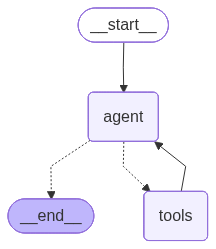

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> __end__;
	agent -.-> tools;
	tools --> agent;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [4]:
from IPython.display import Image, display

arch = ToolUse(max_rounds=4)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))
print(arch.diagram())

## 8 · Live run

Concrete task: time-sensitive research that the model can't possibly have memorized. The question below asks about the *current* state of an open-source project — the model's training cutoff is well in the past, so an honest answer requires real web search and the citation requirement forces grounding.

In [5]:
from datetime import date

TASK = (
    f"As of {date.today().isoformat()}, what is the latest stable Python release "
    f"version, and name 2 user-visible features new in that release. "
    f"You MUST cite at least 1 source URL (e.g. python.org or PEP page) — "
    f"answers without a URL will be considered ungrounded."
)

result = arch.run(TASK)

print_header("Final answer")
print_md(result.output)
print()
print_header(
    f"{result.metadata['tool_calls']} tool call(s)  ·  "
    f"{result.metadata['rounds']} final agent round(s)  ·  "
    f"tools used: {', '.join(result.metadata['tools_used']) or 'none'}"
)

Final answer ──────────────────────────────────────────────────────────────────────────────────────────────────────

The latest stable Python release version as of 2026-05-27 is Python 3.14.5. Two user-visible features new in this  
release are compression.zstd and except* statements.                                                               

For more information, see the official Python blog at https://blog.python.org/2026/05/python-3145-is-out and the   
Python documentation at https://docs.python.org/3.16/whatsnew/3.16.html.

2 tool call(s)  ·  1 final agent round(s)  ·  tools used: tavily_search ───────────────────────────────────────────

### 8.0 · What just happened, briefly

Look at the **tool call count** above. Three regimes you might see, each meaningful:

- **`tool_calls = 0`** — the agent answered from parametric knowledge, ignoring the citation requirement. That's *result drift*, the most dangerous Tool-Use failure mode (the answer *looks* confident but is ungrounded).
- **`tool_calls = 1–3`** — focused use; the agent searched, found enough, answered. This is what we want.
- **`tool_calls ≥ 4`** — *over-search*. The agent kept searching past the point of diminishing returns. Usually a sign that either (a) the model didn't trust the first results, or (b) it ignored its own system-prompt cap.

§ 9 below will quantify which regime this specific run fell into.

### 8.1 · Full trace

Every event the agent took, in order. `tool_call` events show *what the model asked for*; `tool_result` events show what came back; `agent` events are the model's natural-language outputs (only the final one has no tool calls).

In [6]:
for i, t in enumerate(result.trace, 1):
    if t['type'] == 'user':
        print_step(f"[{i}] USER", t['content'][:200])
    elif t['type'] == 'tool_call':
        args = t['args'] if isinstance(t['args'], dict) else str(t['args'])
        query = args.get('query', args) if isinstance(args, dict) else args
        print_step(f"[{i}] TOOL CALL → {t['tool']}", f"`{query}`")
    elif t['type'] == 'tool_result':
        snippet = t['content'][:300].replace('\n', ' ')
        print_step(f"[{i}] TOOL RESULT ({t['tool']})", snippet + '...')
    elif t['type'] == 'agent':
        print_step(f"[{i}] AGENT", (t.get('content') or '')[:300])
    print()

› [1] USER

As of 2026-05-27, what is the latest stable Python release version, and name 2 user-visible features new in that 
release. You MUST cite at least 1 source URL (e.g. python.org or PEP page) — answers wi

› [2] TOOL CALL → tavily_search

`latest stable Python release version and new features`

› [3] TOOL RESULT (tavily_search)

...

`latest stable Python release version and new features`

› [5] TOOL RESULT (tavily_search)

{"query": "latest stable Python release version and new features", "follow_up_questions": null, "answer": null, 
"images": [], "results": [{"url": "https://blog.python.org/2026/05/python-3145-is-out", "title": "Python 3.14.5 is 
out! | Python Insider", "content": "## Major new features of the 3.14 ser...

› [6] AGENT

The latest stable Python release version as of 2026-05-27 is Python 3.14.5. Two user-visible features new in this 
release are `compression.zstd` and `except*` statements. 

For more information, see the official Python blog at https://blog.python.org/2026/05/python-3145-is-out and the 
Python documen

## 9 · What we just observed

The cells above are live. Below: a quantitative breakdown of the **actual** tool-call sequence the Nebius-hosted Llama-3.3-70B agent produced on this run.

### 9.1 · Quantitative summary

| Metric | Value |
|---|---|
| Tool calls made | **2** |
| Tools used | tavily_search |
| Final agent rounds | 1 |
| Final answer length (chars) | 583 |

**Queries the agent issued to Tavily:**

| # | Query |
|---|---|
| 1 | `latest stable Python release version and new features` |
| 2 | `latest stable Python release version and new features` |


### 9.2 · Pathologies surfaced in this run

- **Repeated queries.** 1 of the 2 queries were duplicates. The agent has no memory that it already asked. This is a real limitation of Tool Use — ReAct's *thought* step partly fixes it because the model has to justify each search.


### 9.3 · The final answer (verbatim)

> The latest stable Python release version as of 2026-05-27 is Python 3.14.5. Two user-visible features new in this  
> release are compression.zstd and except* statements.                                                               
> 
> For more information, see the official Python blog at https://blog.python.org/2026/05/python-3145-is-out and the   
> Python documentation at https://docs.python.org/3.16/whatsnew/3.16.html.                                           
> 
> 
> 
> 2 tool call(s)  ·  1 final agent…

### 9.4 · The takeaway

Tool Use is the **right** pattern when the model needs one or two facts from outside its training data. It's the **wrong** pattern when you need:

- *Multi-step reasoning* between calls → use **ReAct (nb 03)**.
- *Guaranteed grounding* of the final answer → use **Self-RAG (nb 25)** or **Corrective RAG (nb 24)**.
- *Recovery* from failed tool calls → use **PEV (nb 06)**.

The pathologies you saw above are not bugs in the implementation — they're inherent to the act-only loop. They motivate the next several notebooks.

## 10 · Try other providers

Tool Use needs **tool-calling support**. The library's capability matrix (`provider_supports_tools`) gates this — providers without tool-calling (e.g., `huggingface`) will refuse to construct `ToolUse(...)`. Everywhere else, the same notebook runs unchanged.

In [7]:
from agentic_architectures.llm.factory import provider_supports_tools

PROVIDERS_TO_TRY = ["openai", "anthropic", "groq"]
for p in PROVIDERS_TO_TRY:
    key = settings.api_key_for(p)
    if key is None or not key.get_secret_value():
        print(f"[skip] {p}: no API key in .env")
        continue
    if not provider_supports_tools(p):
        print(f"[skip] {p}: provider does not advertise tool-calling")
        continue

    print_header(f"Re-running Tool Use on {p}")
    other_llm = get_llm(provider=p)
    other_arch = ToolUse(llm=other_llm, max_rounds=2)
    r = other_arch.run("What is the current price (USD) of one Bitcoin? Cite the source URL.")
    print(r.output[:400])
    print(f"  tool_calls: {r.metadata['tool_calls']}, rounds: {r.metadata['rounds']}")
    print()

[skip] openai: no API key in .env


[skip] anthropic: no API key in .env
[skip] groq: no API key in .env


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Over-search** | Model keeps calling tools even when it has enough info | System prompt cap (we use this) + `max_rounds` bound |
| **Result drift / hallucination** | Tool result is in context but model answers from parametric knowledge anyway | Force grounding in prompt; switch to **Self-RAG (nb 25)** or **Corrective RAG (nb 24)** |
| **Vague queries** | Model issues queries too generic to retrieve anything useful | Add a thought step → upgrade to **ReAct (nb 03)** |
| **Repeated identical queries** | Agent forgets it already asked and re-asks | Maintain a dedup cache; or use a planner (nb 04) |
| **Tool execution errors** | Tool raises (network down, rate limit) and agent doesn't recover | The library's `web_search_tool` wraps with `tenacity` exponential backoff; for tools you write yourself, do the same |
| **Prompt injection through tool output** | Tool result contains adversarial text that hijacks the agent | Treat tool output as untrusted; sanitize / quote when re-prompting |

### 11.2 · Production safety

- **Cap rounds + recursion limit.** Both are configured by default in this library; never remove them.
- **Whitelist tools.** Don't bind every tool you have — give the agent only the tools relevant to the task. Each extra tool widens the prompt-injection surface.
- **Don't let tool output flow to the user verbatim.** A user-asked-for "summary" should still be model-generated, not pasted from a search result the user can't see.
- **Add a per-tool timeout.** A hung tool with no timeout will deadlock the whole graph.

### 11.3 · Three extensions to try

1. **Add a Python REPL tool.** Use `agentic_architectures.tools.code_exec.python_repl_tool` to give the agent arithmetic / data-manipulation power. Useful for "calculate this from the search results" tasks.
2. **Multi-tool agent.** Bind both `web_search_tool` and a domain-specific tool (e.g., a SQL query tool). Watch how the agent picks between them. This is the path toward **Meta-Controller (nb 11)**.
3. **Swap to ReAct (nb 03).** Same task, with explicit *thought* before each action. You'll see the agent's queries get more specific because it has to write a justification first.

### 11.4 · What to read next

- [**03 · ReAct**](./03_react.ipynb) — Tool Use + an explicit reasoning step. The natural next stop.
- [**04 · Planning**](./04_planning.ipynb) — when the task is big enough that planning ahead beats reacting.
- [**06 · PEV**](./06_pev.ipynb) — Tool Use + an automatic verifier that catches bad tool outcomes.
- [**23 · Agentic RAG**](./23_agentic_rag.ipynb) — Tool Use where the tool is a vector retriever and the agent decides when to retrieve.

### 11.5 · References

1. Schick, T. et al. *Toolformer: Language Models Can Teach Themselves to Use Tools.* 2023. [arXiv:2302.04761](https://arxiv.org/abs/2302.04761)
2. OpenAI. *Function calling and other API updates.* June 2023. [openai.com/blog/function-calling-and-other-api-updates](https://openai.com/blog/function-calling-and-other-api-updates)
3. LangGraph `ToolNode` & `tools_condition` — [official prebuilts docs](https://langchain-ai.github.io/langgraph/reference/prebuilt/)
4. Tavily search API — [tavily.com](https://tavily.com)
